---
<a name='title'></a>
# **<font color="Navy"> Temas Selectos </font>**
## **<font color="RoyalBlue"> Tema 3: Estadística aplicada </font>**
### **<font color="DodgerBlue"> Notebook 1: Normalización de datos </font>**
#### Escuela Nacional de Ciencias de la Tierra
#### Semestre 2026-II

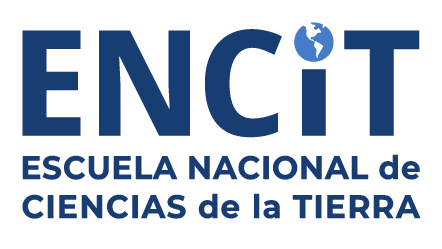

---

### **<font color="ForestGreen"> Introducción a la normalización de datos </font>**


### **<font color="ForestGreen">Normalización y estandarización</font>**

**Normalizar** datos significa transformar sus valores a una escala común sin distorsionar las diferencias en los rangos de valores originales. Sin embargo, el término se usa de manera ambigua en la práctica, por lo que conviene distinguir tres conceptos:

| Concepto | Qué hace | Rango resultante | Fórmula |
|---|---|---|---|
| **Normalización** (Min-Max) | Reescala al rango $[0, 1]$ usando mínimo y máximo | $[0, 1]$ | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ |
| **Estandarización** (Z-score) | Transforma a media = 0 y desviación estándar = 1 | Sin límite fijo | $x' = \frac{x - \mu}{\sigma}$ |
| **Reescalado** | Término genérico para cualquier cambio de escala | Variable | — |

La **estandarización** es más robusta ante valores atípicos porque no depende del mínimo y máximo. La **normalización** es preferible cuando el algoritmo requiere valores estrictamente en $[0, 1]$.

> ⚠️ **Nota:** Existe confusión porque muchos usan *"normalización"* como término paraguas para cualquier preprocesamiento de escala, cuando en realidad son conceptos con propiedades matemáticas distintas.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
# Datos 1D con outliers (simula mediciones)
rng = np.random.default_rng(42)
x = np.r_[rng.normal(10, 2, 200), [30, 35]]   # dos outliers

Text(0.5, 1.0, 'Datos originales')

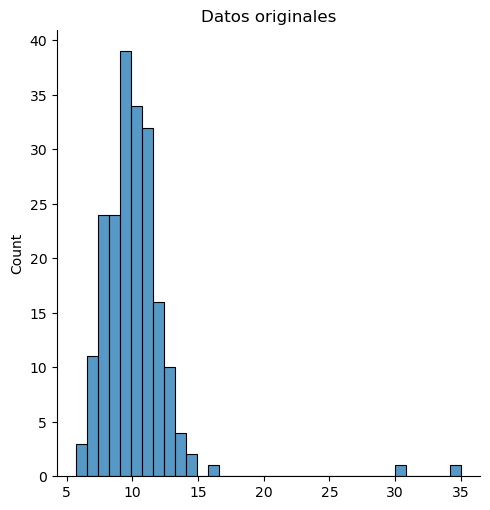

In [4]:
sns.displot(x)
plt.title('Datos originales')

In [5]:
# Estadísticos
x_min, x_max = np.min(x), np.max(x)
x_mean, x_std = np.mean(x), np.std(x)

Usando estos estadísticos podemos usar la versión Min-max para transformar nuestros datos, siguiendo la fórmula: 

\begin{equation}
X_{min,max}\;=\; \frac{x - min(x)}{max(x)-min(x)}
\end{equation}

In [6]:
# Transformaciones
x_minmax = (x - x_min) / (x_max - x_min)     # [0,1]

## ¿Por qué visualizar la distribución de tus datos?

Antes de aplicar cualquier modelo o transformación, conocer la distribución de tus datos es esencial. Visualizarla te permite:

- **Detectar sesgos** (*skewness*): datos concentrados a un lado afectan modelos que asumen normalidad.
- **Identificar outliers**: valores extremos que distorsionan métricas como la media.
- **Validar transformaciones**: tras normalizar, podemos confirmar visualmente que los datos están en el rango esperado.

> Un histograma puede revelar problemas que las estadísticas descriptivas ocultan.

---

## ¿Qué es Seaborn?

[Seaborn](https://seaborn.pydata.org/) es una librería de visualización estadística en Python construida sobre Matplotlib. Permite crear gráficas informativas con pocas líneas de código y se integra bien con pandas.

### Distribuciones con `sns.displot()`
```python
sns.displot(x_minmax)
plt.title('Datos Normalizados')
```

Genera un **histograma** con una curva **KDE** (*Kernel Density Estimate*) superpuesta, que suaviza el histograma para estimar la distribución subyacente. En este caso, al usar MinMaxScaler, esperamos ver los valores distribuidos entre **0 y 1**.

Text(0.5, 1.0, 'Datos Normalizados')

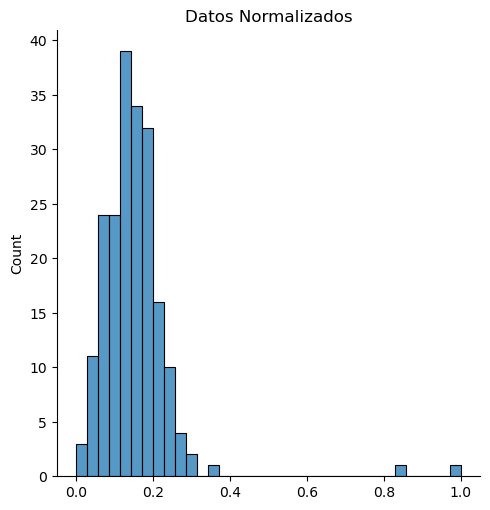

In [7]:
sns.displot(x_minmax)
plt.title('Datos Normalizados')

## Estandarización con Z-score

El **Z-score** mide cuántas desviaciones estándar se aleja un valor de la media. Se define como:

$$z = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ la desviación estándar.

El resultado es una distribución con **media = 0** y **desviación estándar = 1**, lo que facilita comparar variables en distintas escalas.



In [8]:
z=(x-x_mean)/x_std

In [9]:
np.mean(z)

1.670830690524988e-16

Text(0.5, 1.0, 'Datos Normalizados')

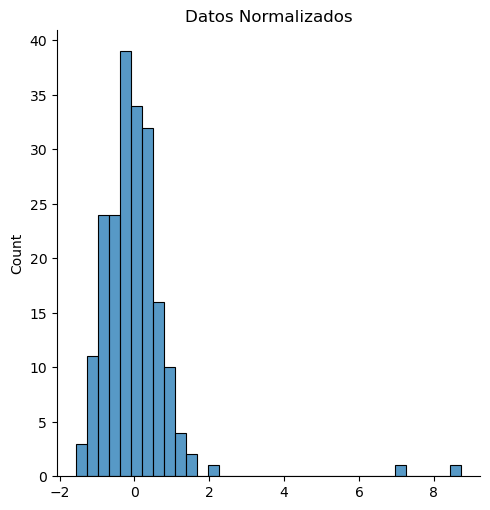

In [10]:
sns.displot(z)
plt.title('Datos Normalizados')

---

**Ejemplo con el dataset Iris:**
```python
import pandas as pd
from sklearn.datasets import load_iris  # solo para cargar los datos

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.describe().round(2)
```



In [11]:
from sklearn.datasets import load_iris

In [12]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [13]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Text(0.5, 1.0, 'Datos Originales')

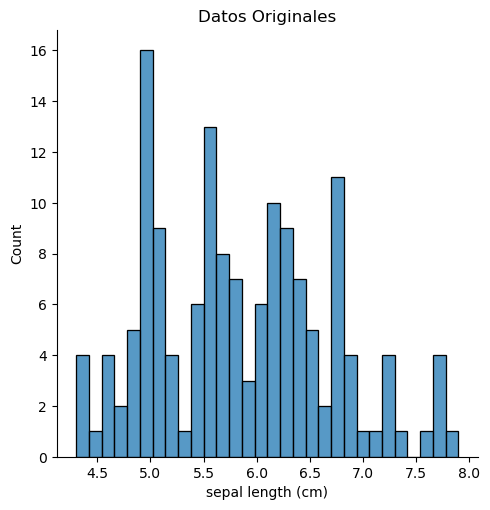

In [14]:
sns.displot(df,x='sepal length (cm)',bins=30)
plt.title('Datos Originales')

**Normalización Min-Max** → escala cada columna a $[0, 1]$:
```python
df_norm = (df - df.min()) / (df.max() - df.min())
```

In [15]:
df_norm = (df - df.min()) / (df.max() - df.min())

La funcion describe nos muestra un resumen estadístico (descriptivo) de los datos incluyendo min-max, etc. 

In [16]:
df_norm.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,0.43,0.44,0.47,0.46
std,0.23,0.18,0.30,0.32
min,0.00,0.00,0.00,0.00
25%,0.22,0.33,0.10,0.08
50%,0.42,0.42,0.57,0.50
75%,0.58,0.54,0.69,0.71
max,1.00,1.00,1.00,1.00


In [17]:
df_norm.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

Text(0.5, 1.0, 'Datos Normalizados Min-Max')

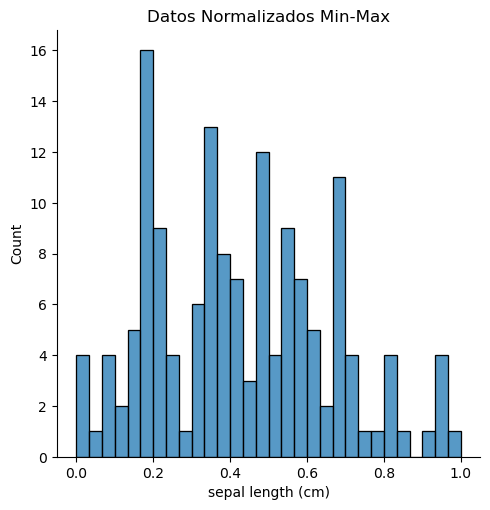

In [20]:
sns.displot(df_norm,x='sepal length (cm)',bins=30)
plt.title('Datos Normalizados Min-Max')

**Estandarización Z-score** → media ≈ 0, desviación estándar = 1:
```python
df_std = (df - df.mean()) / df.std()
df_std.describe().round(2)  # mean≈0.0, std=1.0 en todas las columnas
```

In [21]:
df_std = (df - df.mean()) / df.std()
df_std.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.86,-2.43,-1.56,-1.44
25%,-0.90,-0.59,-1.22,-1.18
50%,-0.05,-0.13,0.34,0.13
75%,0.67,0.56,0.76,0.79
max,2.48,3.08,1.78,1.71


Text(0.5, 1.0, 'Datos Normalizados con Z-score')

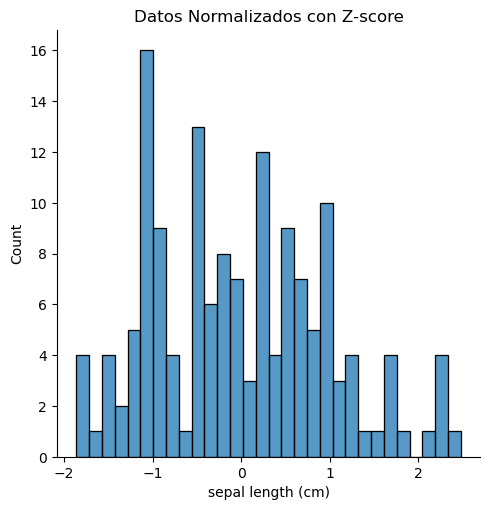

In [22]:
sns.displot(df_std,x='sepal length (cm)',bins=30)
plt.title('Datos Normalizados con Z-score')

---
<a name='ej-1'></a>
### **<font color="DodgerBlue">Ejercicio 1 - Normalización de datos de pétalos </font>**

<font color="DarkBlue"> 1. Muestre ahora la comparativa entre los datos originales, y los normalizados (vía Min-Max y $Z$ score) para la columna de `petal_width`. 
        
---

    Extra: ¿Puede lograrlo en una sola gráfica?

Normalizaciones usadas y sus fórmulas (con pros y diferencias)

1) Proporción respecto a la media
   Fórmula:  $x' = \dfrac{x}{\mu}$
   Dónde: $\mu$ es la media del conjunto.
   Ventajas: convierte valores en “veces la media”; útil para índices adimensionales y comparaciones relativas.
   Diferencias: no centra en 0 ni controla la dispersión; sensible a valores atípicos que alteren $\mu$. No usar si $\mu \approx 0$.

2) Max-Abs (escala a [-1, 1])
   Fórmula: $x' = \dfrac{x}{\max(|x|)}$
   Dónde: $\max(|x|)$ es el valor absoluto máximo.
   Ventajas: mantiene la forma de la distribución y la dispersión relativa; útil cuando ya está centrado y se requiere cota simétrica.
   Diferencias: muy sensible a outliers (si hay uno muy grande, comprime el resto); no centra en 0 ni homogeneiza varianza.

3) Normalización L2 (norma unitaria)
   Fórmula: $x' = \dfrac{x}{\|x\|_2}$, con $\|x\|_2 = \sqrt{\sum_i x_i^2}$
   Ventajas: fija la longitud del vector a 1; útil en métodos geométricos (similitud de coseno, modelos que usan productos punto).
   Diferencias: escala global del vector; no centra ni ajusta varianza elemento a elemento; sensible a outliers grandes.

4) Estandarización (Z-score)
   Fórmula: $z = \dfrac{x - \mu}{\sigma}$
   Ventajas: centra en 0 y pone varianza unitaria; apropiada para modelos lineales, regularización y comparación entre variables.
   Diferencias: no limita a un rango fijo; sensible a outliers (mejor usar versiones robustas si hay colas pesadas).



### **<font color="ForestGreen">Normalizaciones: fórmulas, ventajas y diferencias</font>**

A continuación se presentan las transformaciones de escala más comunes, sus propiedades matemáticas y cuándo conviene (o no) usarlas:

---

#### 1. Proporción respecto a la media

$$x' = \frac{x}{\mu}$$

donde $\mu$ es la media del conjunto. Convierte cada valor en *"veces la media"*, lo que lo hace útil para índices adimensionales y comparaciones relativas.

> ⚠️ No usar si $\mu \approx 0$. No centra en 0 ni controla la dispersión; sensible a valores atípicos que alteren $\mu$.

---

#### 2. Max-Abs (escala a $[-1, 1]$)

$$x' = \frac{x}{\max(|x|)}$$

donde $\max(|x|)$ es el valor absoluto máximo del conjunto. Mantiene la forma de la distribución y la dispersión relativa; útil cuando los datos ya están centrados y se requiere una cota simétrica.

> ⚠️ Muy sensible a outliers: si existe un valor muy grande, comprime el resto. No centra en 0 ni homogeneiza la varianza.

---

#### 3. Normalización L2 (norma unitaria)

$$x' = \frac{x}{\|x\|_2}, \quad \text{con} \quad \|x\|_2 = \sqrt{\sum_i x_i^2}$$

Fija la longitud del vector a 1. Útil en métodos geométricos como similitud de coseno o modelos que operan con productos punto.

> ⚠️ Opera sobre el vector completo, no elemento a elemento. No centra ni ajusta la varianza; sensible a outliers de gran magnitud.

---

#### 4. Estandarización (Z-score)

$$z = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ la desviación estándar. Centra los datos en 0 y produce varianza unitaria; apropiada para modelos lineales, regularización L1/L2 y comparación entre variables de distintas unidades.

> ⚠️ No limita a un rango fijo. Sensible a outliers en distribuciones con colas pesadas; en esos casos considerar versiones robustas (usando mediana y MAD).

---

| Método | Rango resultante | Centra en 0 | Varianza unitaria | Sensible a outliers |
|---|---|---|---|---|
| Proporción a la media | Sin límite fijo | ✗ | ✗ | ✓ |
| Max-Abs | $[-1, 1]$ | ✗ | ✗ | ✓✓ |
| Normalización L2 | $[-1, 1]$ (norma) | ✗ | ✗ | ✓ |
| Estandarización Z | Sin límite fijo | ✓ | ✓ | ✓ |


https://ourworldindata.org/

In [23]:
x_overmu = x / (x_mean)                      # proporción respecto a la media

In [24]:
x_maxabs = x / (np.max(np.abs(x)))           # dvidir por el máximo absoluto, quedando en [-1,1]

In [25]:
x_l2 = x / (np.linalg.norm(x))    # Sacar la norma y dividir 

In [26]:
x_zscore = (x - x_mean) / (x_std) # Z-score

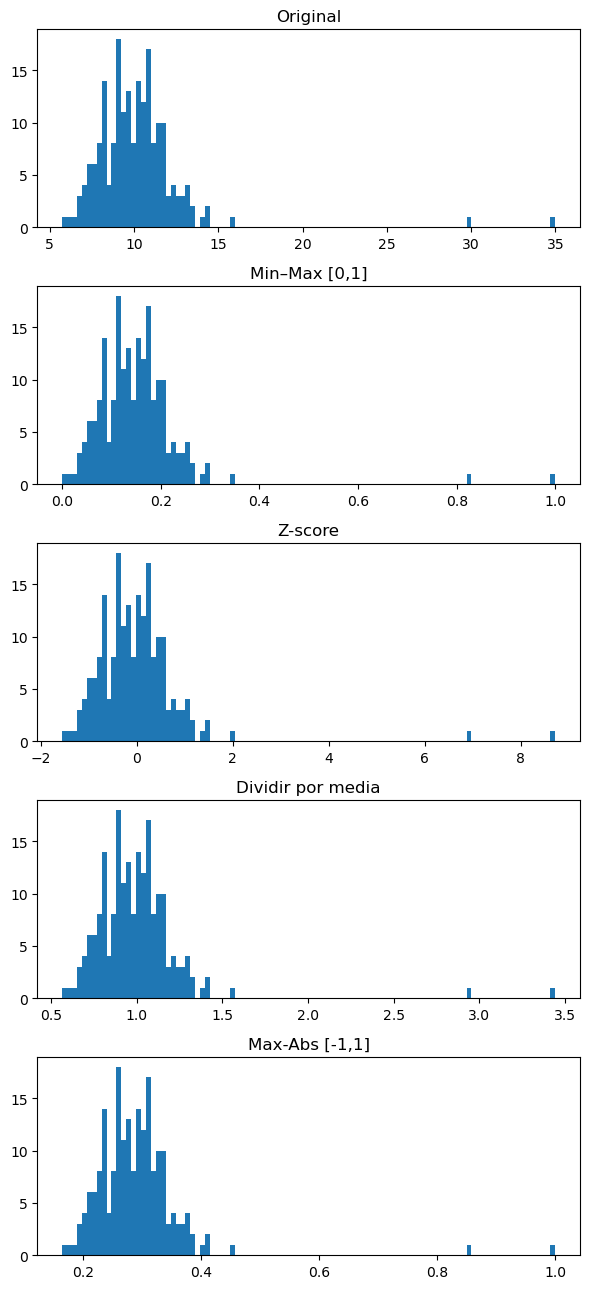

In [27]:
# Visualización comparativa
fig, axes = plt.subplots(5, 1, figsize=(6, 13), sharey=False)
axes[0].hist(x, bins=100)
axes[0].set_title("Original")
axes[1].hist(x_minmax, bins=100)
axes[1].set_title("Min–Max [0,1]")
axes[2].hist(x_zscore, bins=100)
axes[2].set_title("Z-score")
axes[3].hist(x_overmu,bins=100)
axes[3].set_title("Dividir por media")
axes[4].hist(x_maxabs, bins=100)
axes[4].set_title("Max-Abs [-1,1]")
plt.tight_layout()


In [28]:
# --- Malla 2D ---
nx, ny = 200, 200
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

# --- Campo 3D (Z sobre el plano 2D) ---
# combinación de dos “lomas/valle” + ondulación suave
Z = 10*(np.exp(-((X-0.30)**2 + (Y-0.40)**2) / 0.02)               # loma 1
    - 0.6*np.exp(-((X-0.75)**2 + (Y-0.70)**2) / 0.01)         # valle
    + 0.15*np.sin(6*np.pi*X)*np.cos(4*np.pi*Y)                # ondulación
)

In [29]:
Zmin, Zmax = Z.min(), Z.max()

In [30]:
# --- Estandarización ---
Z_mu, Z_sd = Z.mean(), Z.std()
Z_z = (Z - Z_mu) / (Z_sd)
Z_scaled = (Z-Zmin)/(Zmax-Zmin)

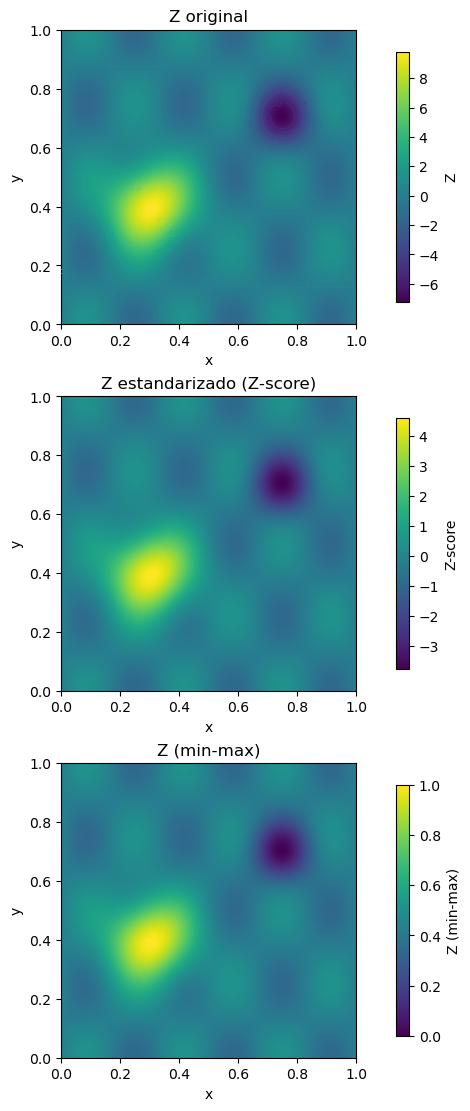

In [32]:
# --- Visualización: original y z-score ---
fig, axs = plt.subplots(3, 1, figsize=(7,11), constrained_layout=True)

im0 = axs[0].imshow(Z, origin="lower", extent=(0,1,0,1), aspect="equal")
axs[0].set_title("Z original")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
plt.colorbar(im0, ax=axs[0], shrink=0.85, label="Z")

# Contornos opcionales para realzar estructura
cs = axs[0].contour(X, Y, Z, levels=10, linewidths=0.8)
axs[0].clabel(cs, inline=True, fontsize=8)

im1 = axs[1].imshow(Z_z, origin="lower", extent=(0,1,0,1), aspect="equal")
axs[1].set_title("Z estandarizado (Z-score)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
plt.colorbar(im1, ax=axs[1], shrink=0.85, label="Z-score")

im1 = axs[2].imshow(Z_scaled, origin="lower", extent=(0,1,0,1), aspect="equal")
axs[2].set_title("Z (min-max)")
axs[2].set_xlabel("x")
axs[2].set_ylabel("y")
plt.colorbar(im1, ax=axs[2], shrink=0.85, label="Z (min-max)")

### **<font color="ForestGreen"> Ejemplo/Ejercicio </font>**

Abrir la base de datos de GPCP, ya sea que ya lo tenga descargado o lo puede descargar via wget a través del link: 'https://downloads.psl.noaa.gov//Datasets/gpcp/precip.mon.mean.nc'. 

1. Leer los datos usando xarray y seleccionando la variable 'precip'.

`ds=xr.open_dataset('/precip.mon.mean.nc')`

2. Calcular los estadísticos necesarios para la normalización ($\mu$, $\sigma$, $min$ y $max$) con respecto al tiempo total y luego con respecto a la coordenada del mes `ds.time.dt.month`.  

`clim=precip.mean('time')`

3. Calcule el promedio por mes de la precipitación usando una operación del tipo 'groupby' y seleccione el mes de su cumpleaños. 

`precip_month=precip.groupby(precip.time.dt.month).mean()`

4. Haga un mapa de la anomalía calculada como la diferencia entre el promedio de su mes de cumpleaños y el promedio climatológico.

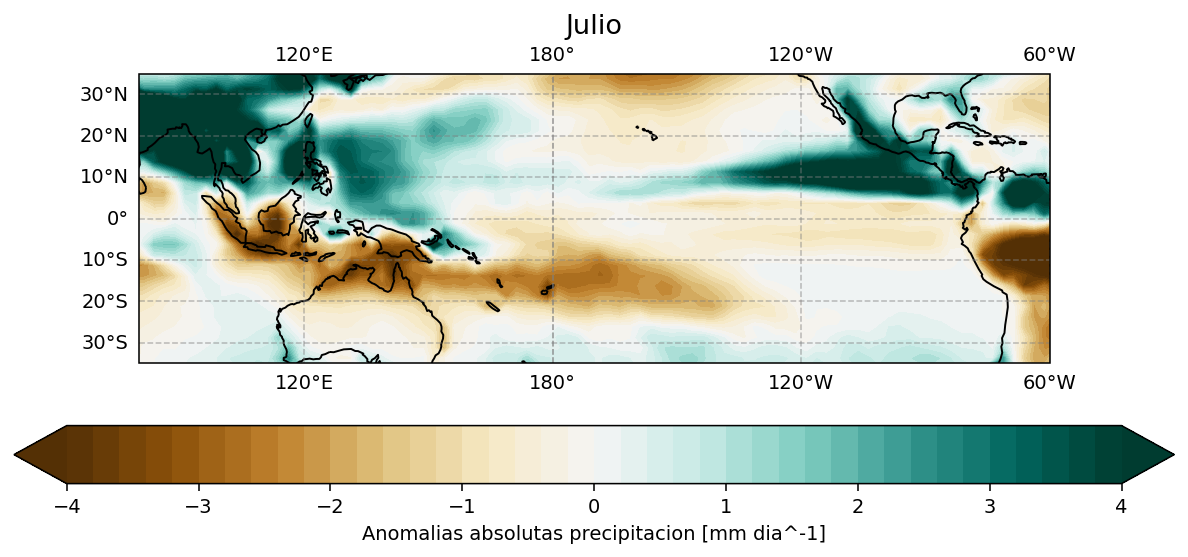

5. Repita para anomalias estandarizadas mediante el Z-score que requiere el promedio climatológico y la desviación estándar que calculó en la parte anterior.

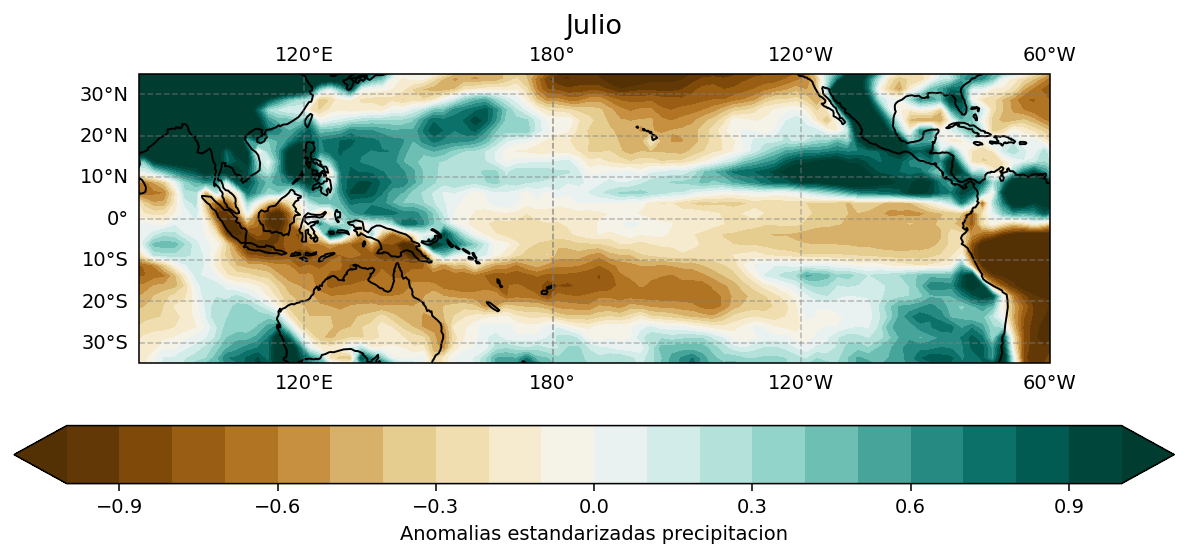


#### **<font color="ForestGreen"> 6. Extra> </font>**
 ¿Cree que puede repetir el ejercicio usando otro tipo de normalización? ¿Puede calcular la anomalía de su mes exacto de cumpleaños? Por ejemplo, el del profe que sería el 1 de julio del año 2000.